In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

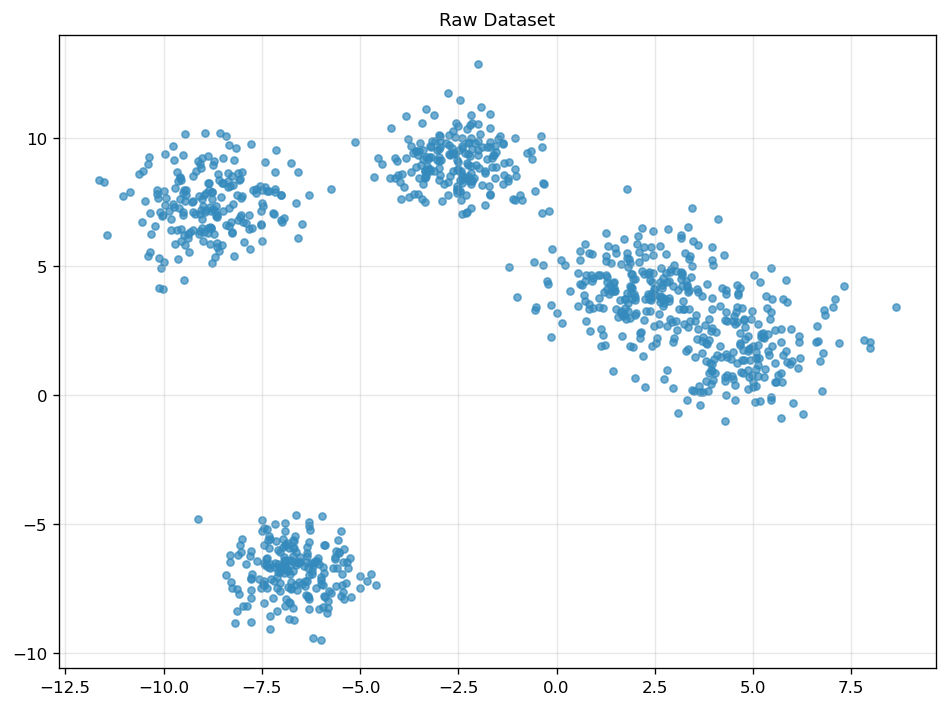

In [3]:
np.random.seed(42)

samples = [200, 200, 200, 200, 200]
stds = [1.0, 1.3, 0.9, 1.1, 1.2]

X, y = make_blobs(
    n_samples=samples,
    n_features=2,
    centers=None,
    cluster_std=stds,
    random_state=42
)

# 原始数据绘图
plt.figure(figsize=(8, 6), dpi=120)
plt.scatter(X[:, 0], X[:, 1], c="#348abd", s=18, alpha=0.7)
plt.title("Raw Dataset", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


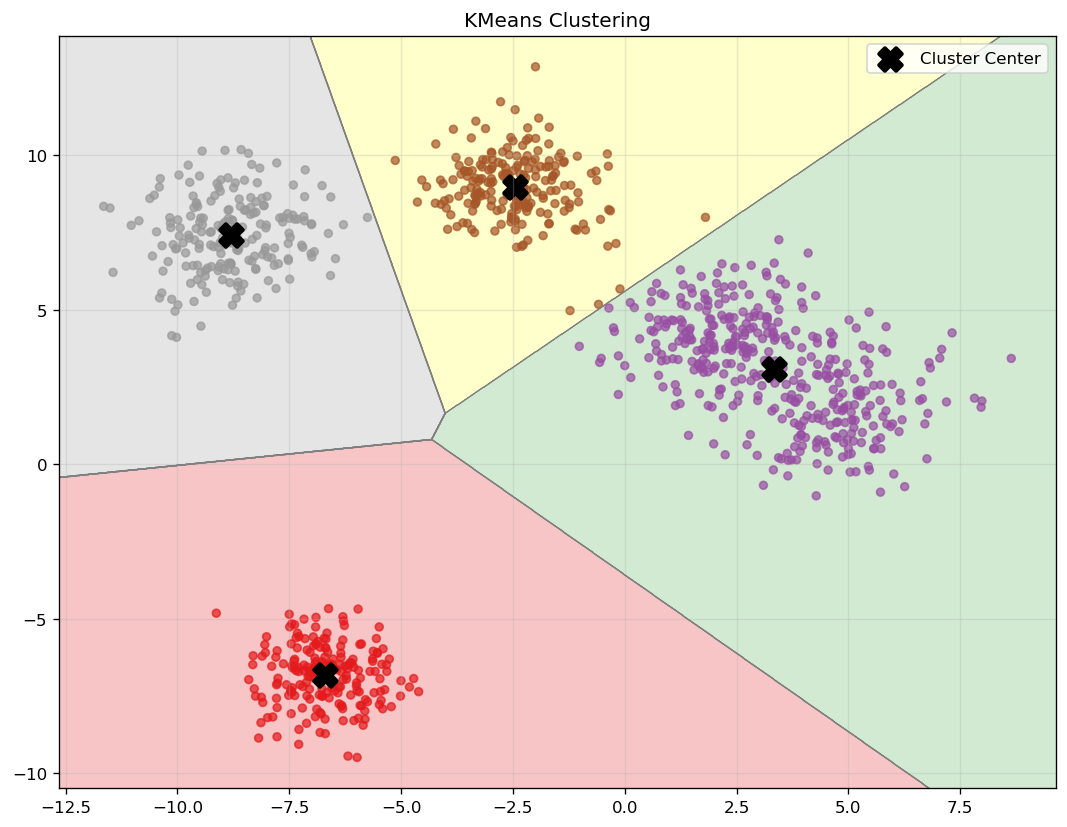

In [4]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(9,7), dpi=120)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# 预测网格每个点所属类别
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制区域底色与分界线
plt.contourf(xx, yy, Z, alpha=0.25, cmap="Set1")
plt.contour(xx, yy, Z, colors="gray", linewidths=0.7)

# 2. 样本点，按预测簇上色
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap="Set1", s=22, alpha=0.7)

# 3. 绘制质心
plt.scatter(centers[:,0], centers[:,1], marker="X", c="black", s=180, lw=2.5, label="Cluster Center")

plt.title(f"KMeans Clustering", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


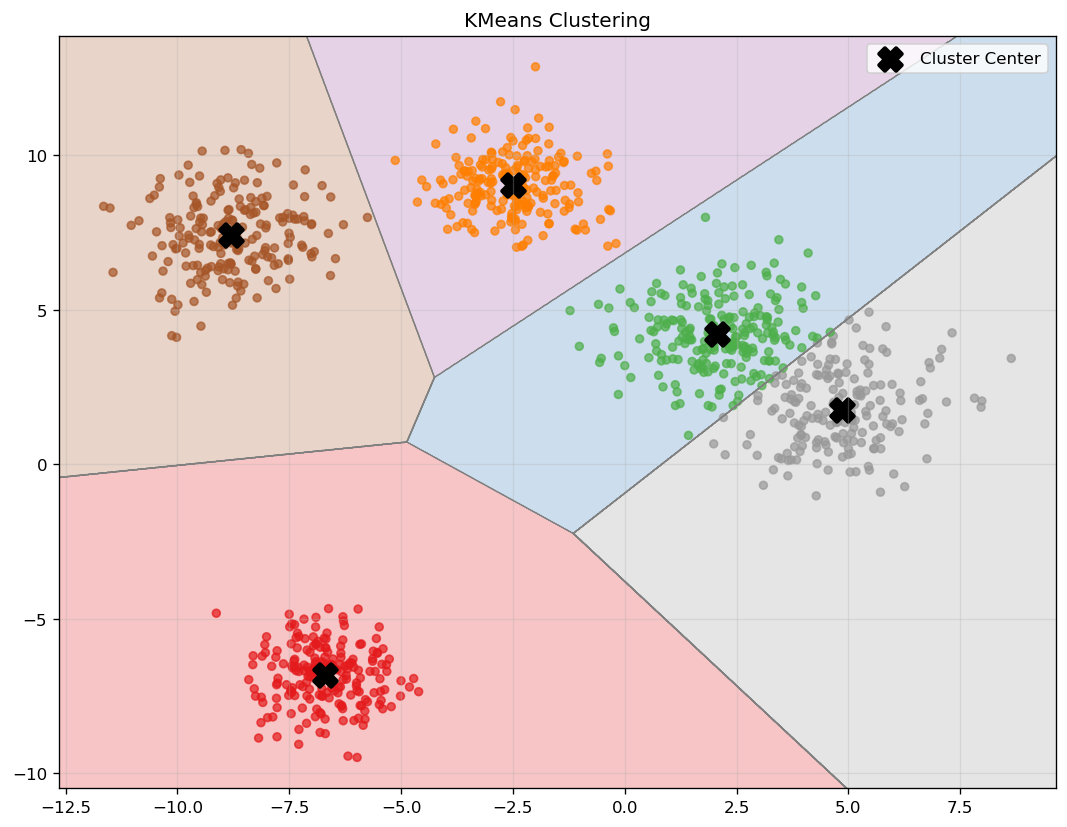

In [5]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(9,7), dpi=120)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# 预测网格每个点所属类别
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制区域底色与分界线
plt.contourf(xx, yy, Z, alpha=0.25, cmap="Set1")
plt.contour(xx, yy, Z, colors="gray", linewidths=0.7)

# 2. 样本点，按预测簇上色
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap="Set1", s=22, alpha=0.7)

# 3. 绘制质心
plt.scatter(centers[:,0], centers[:,1], marker="X", c="black", s=180, lw=2.5, label="Cluster Center")

plt.title(f"KMeans Clustering", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**如何确定最好的集群数量**

**肘点法**
惯性：所有实例与其最近的质心时间的平方距离之和
随着 k 的增加，模型的惯性会不断降低

绘制模型关系随 k 的变化曲线，曲线的肘点（惯性下降突然变缓的点）即为最好的 k 值

从下面的结果可见，该方法并不好

**轮廓系数法**
轮廓系数：$\frac{b-a}{max(a,b)}$
- a: 实例与同一集群中其他实例的平均距离，a 越小， 簇内部越紧密
- b: 实例到最近的一个集群中的实例的平均距离，b 越大，簇与簇 之间分得越开
所有实例的平均轮廓系数越接近1，则聚类效果越好

d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklea

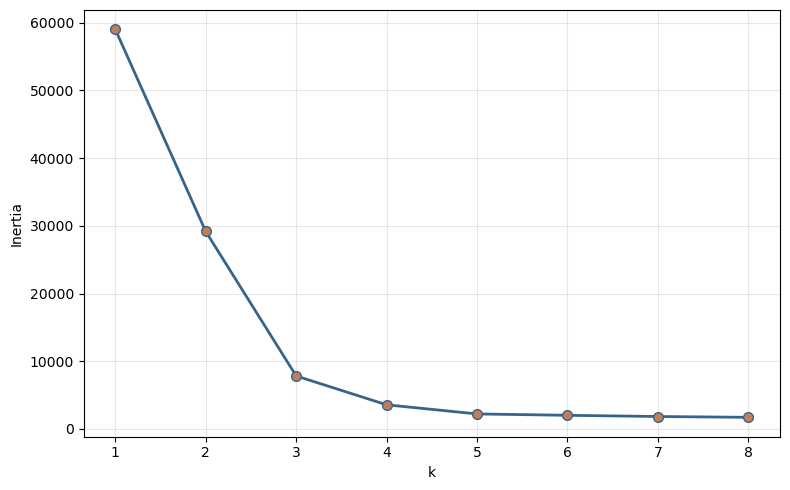

In [8]:
k_range = range(1, 9)
inertias = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# 3. 绘制肘部曲线
plt.figure(figsize=(8, 5))
# 柔和配色
line_color = "#36648B"
marker_color = "#C27E59"
plt.plot(k_range, inertias, color=line_color, marker='o', markerfacecolor=marker_color, markeredgecolor=line_color, linewidth=2, markersize=7)

plt.xlabel("k")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\machine_learning\lib\site-packages\sklea

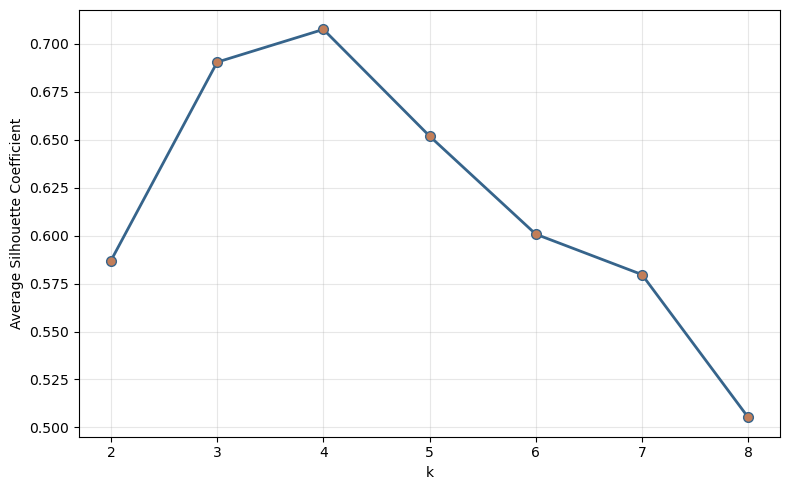

In [9]:
from sklearn.metrics import silhouette_score

k_list = list(range(2, 9))
sil_avg_scores = []

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels = km.fit_predict(X)
    avg_score = silhouette_score(X, cluster_labels)
    sil_avg_scores.append(avg_score)

plt.figure(figsize=(8, 5))
line_color = "#36648B"
marker_fill = "#C27E59"

plt.plot(k_list, sil_avg_scores,
         color=line_color,
         marker="o",
         markerfacecolor=marker_fill,
         markeredgecolor=line_color,
         linewidth=2,
         markersize=7)

plt.xlabel("k")
plt.ylabel("Average Silhouette Coefficient")
plt.xticks(k_list)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

进行 K-means 聚类前，要先对输入特征进行无量纲化

当集群具有不同的大小、不同的密度或非球形时，K-means 算法表现不佳